# SDC loader + barplot du nombre de points par tranche de 5 s

Ce notebook :
- charge un fichier `.sdc`
- applique un filtrage brut simple sur `t/x/y/z`
- affiche des stats de base
- calcule le nombre de points par tranche temporelle de `5 s`
- trace un barplot


In [5]:
from pathlib import Path
import os
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [2]:

def loadLasVecSDC(sdc_file, chunk_records=2_000_000):
    """
    Fast SDC reader with tqdm progress bar.
    Matches legacy mapping exactly:
      record[[0, 3, 4, 5]]

    Returns:
        ndarray (N, 5): [time, x, y, z, u6]
    """
    sdc_file = Path(sdc_file)

    with open(sdc_file, "rb") as f:
        header_info = f.read(8)
        size_of_header = struct.unpack("<I", header_info[:4])[0]

    record_dtype = np.dtype([
        ("t",    "<f8"),  # field 0
        ("f1",   "<f4"),  # field 1
        ("f2",   "<f4"),  # field 2
        ("x",    "<f4"),  # field 3
        ("y",    "<f4"),  # field 4
        ("z",    "<f4"),  # field 5
        ("u6",   "<u2"),
        ("u7",   "<u2"),
        ("u8",   "u1"),
        ("u9",   "u1"),
        ("u10",  "u1"),
        ("u11",  "<u2"),
        ("u12",  "u1"),
        ("u13",  "u1"),
        ("f14",  "<f4"),
        ("u15",  "<u2"),
    ])

    file_size = os.path.getsize(sdc_file)
    payload_size = file_size - size_of_header
    record_size = record_dtype.itemsize

    if payload_size % record_size != 0:
        raise ValueError(
            f"Invalid SDC size: payload={payload_size} not divisible by record size={record_size}"
        )

    record_count = payload_size // record_size

    # Preallocate final output directly
    records = np.empty((record_count, 5), dtype=np.float64)

    write_pos = 0
    total_invalid = 0

    with open(sdc_file, "rb") as f:
        f.seek(size_of_header)

        with tqdm(
            total=record_count,
            desc=f"Reading SDC {sdc_file.name}",
            unit="pts",
            mininterval=0.5,
        ) as pbar:
            while True:
                data = np.fromfile(f, dtype=record_dtype, count=chunk_records)
                n0 = len(data)
                if n0 == 0:
                    break

                valid = (
                    np.isfinite(data["t"]) &
                    np.isfinite(data["x"]) &
                    np.isfinite(data["y"]) &
                    np.isfinite(data["z"])
                )

                n_bad = int(n0 - np.count_nonzero(valid))
                if n_bad > 0:
                    total_invalid += n_bad

                data = data[valid]
                n = len(data)

                if n > 0:
                    records[write_pos:write_pos+n, 0] = data["t"]
                    records[write_pos:write_pos+n, 1] = data["x"]
                    records[write_pos:write_pos+n, 2] = data["y"]
                    records[write_pos:write_pos+n, 3] = data["z"]
                    records[write_pos:write_pos+n, 4] = data["u6"]
                    write_pos += n

                # on garde la progression sur le nombre brut de records lus
                pbar.update(n0)

    if total_invalid > 0:
        print(f"[SDC] Dropped {total_invalid} raw records with non-finite t/x/y/z")

    if write_pos != record_count:
        records = records[:write_pos]

    dt = np.diff(records[:, 0])
    bad = np.where(dt < 0)[0]
    if len(bad) > 0:
        for i in bad:
            jump = dt[i]
            print(f"[SDC] Saut négatif détecté à idx={i} ({i/len(records)*100:.1f}%) : Δt={jump:.4f}s — correction appliquée")
            records[i+1:, 0] -= jump  # soustrait le delta négatif = ajoute |delta|

    return records



In [7]:
# ============================================================
# USER INPUT
# ============================================================
sdc_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/PUCK_SDC/lidar_20260225_160632.sdc")

# Filtrage brut optionnel
abs_t_max = 1e8
abs_xyz_max = 1e4

# Taille des bins temporels
bin_size_s = 30.0


In [4]:
lasvec = loadLasVecSDC(sdc_path)
print("Loaded shape:", lasvec.shape)

mask_valid_raw = (
    np.isfinite(lasvec[:, 0]) &
    np.isfinite(lasvec[:, 1]) &
    np.isfinite(lasvec[:, 2]) &
    np.isfinite(lasvec[:, 3]) &
    (np.abs(lasvec[:, 0]) < abs_t_max) &
    (np.abs(lasvec[:, 1]) < abs_xyz_max) &
    (np.abs(lasvec[:, 2]) < abs_xyz_max) &
    (np.abs(lasvec[:, 3]) < abs_xyz_max)
)

n_bad_raw = int((~mask_valid_raw).sum())
print("Raw invalid rows:", n_bad_raw)

lasvec = lasvec[mask_valid_raw]
print("After raw filter:", lasvec.shape)


Reading SDC lidar_20260225_160632.sdc:   0%|          | 0/122985831 [00:00<?, ?pts/s]

[SDC] Dropped 219895 raw records with non-finite t/x/y/z
Loaded shape: (122765936, 5)
Raw invalid rows: 29359908
After raw filter: (93406028, 5)


In [5]:
t = lasvec[:, 0]

print("t min:", np.nanmin(t))
print("t max:", np.nanmax(t))
print("q0.1% :", np.quantile(t, 0.001))
print("q1%   :", np.quantile(t, 0.01))
print("q50%  :", np.quantile(t, 0.50))
print("q99%  :", np.quantile(t, 0.99))
print("q99.9%:", np.quantile(t, 0.999))


t min: -99992752.43953964
t max: 99998736.35048947
q0.1% : -4054146.014609666
q1%   : -4.821673232632386e-07
q50%  : 317294.136642886
q99%  : 467170.96902115503
q99.9%: 13390228.868419722


In [6]:
# Histogramme temporel par tranches de 5 s
t0 = np.floor(t.min() / bin_size_s) * bin_size_s
t1 = np.ceil(t.max() / bin_size_s) * bin_size_s

bin_edges = np.arange(t0, t1 + bin_size_s, bin_size_s)
counts, edges = np.histogram(t, bins=bin_edges)
centers = 0.5 * (edges[:-1] + edges[1:])

counts_df = pd.DataFrame({
    "bin_start_s": edges[:-1],
    "bin_end_s": edges[1:],
    "bin_center_s": centers,
    "n_points": counts,
})

counts_df.head()


,bin_start_s,bin_end_s,bin_center_s,n_points
0,-99992760.0,-99992740.0,-99992750.0,1
1,-99992740.0,-99992720.0,-99992730.0,0
2,-99992720.0,-99992700.0,-99992710.0,0
3,-99992700.0,-99992680.0,-99992690.0,0
4,-99992680.0,-99992660.0,-99992670.0,0


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(counts_df["bin_start_s"], counts_df["n_points"], width=bin_size_s, align="edge")
ax.set_xlabel("GPS time bin start [s]")
ax.set_ylabel("Number of points")
ax.set_title(f"Number of SDC points per {bin_size_s:.1f} s bin")
plt.show()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7b8655c96f40>>
Traceback (most recent call last):
  File "/home/b085164/miniconda3/envs/limatch/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7b8510fc5af0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
counts_nonzero = counts_df[counts_df["n_points"] > 0].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(counts_nonzero["bin_start_s"], counts_nonzero["n_points"], width=bin_size_s, align="edge")
ax.set_xlabel("GPS time bin start [s]")
ax.set_ylabel("Number of points")
ax.set_title(f"Non-zero bins only ({bin_size_s:.1f} s)")
plt.show()


In [ ]:
csv_out = sdc_path.with_suffix("")
csv_out = csv_out.parent / f"{csv_out.name}_counts_{int(bin_size_s)}s.csv"
counts_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)


In [6]:
records = loadLasVecSDC("/media/b085164/LaCie/2026spring_RD/ECCR/VUX_SDC/HA/260225_154000_VUX-HA1.sdc")
# à ce stade la correction est déjà appliquée dans loadLasVecSDC
t = records[:, 0]
dt = np.diff(t)
bad = np.where(dt < 0)[0]
print(f"Sauts résiduels après correction : {len(bad)}")
for i in bad[:10]:
    print(f"  idx={i} ({i/len(t)*100:.1f}%)  {t[i]:.4f} -> {t[i+1]:.4f}  Δt={dt[i]:.4f}s")

Reading SDC 260225_154000_VUX-HA1.sdc:   0%|          | 0/32669974 [00:00<?, ?pts/s]

[SDC] Saut négatif détecté à idx=24440474 (74.8%) : Δt=-2.0000s — correction appliquée
Sauts résiduels après correction : 0


In [8]:
#records = loadLasVecSDC("260225_154000_VUX-HA1.sdc")
i = 24440474
print(records[i-3:i+5, :])  # t, x, y, z autour du saut

[[ 5.64310000e+04  5.96692038e+00 -1.06626117e+00 -1.09662032e-02
   3.11000000e+03]
 [ 5.64310000e+04  5.96664667e+00 -1.05925691e+00 -1.09602520e-02
   3.13400000e+03]
 [ 5.64310000e+04  5.96644211e+00 -1.05181491e+00 -1.09540839e-02
   3.03900000e+03]
 [ 5.64310000e+04  5.96856976e+00 -1.04402959e+00 -1.09516038e-02
   3.07900000e+03]
 [ 5.64310000e+04  5.96711493e+00 -1.03667712e+00 -1.09434081e-02
   3.08700000e+03]
 [ 5.64310000e+04  5.96666241e+00 -1.02874947e+00 -1.09364726e-02
   3.13300000e+03]
 [ 5.64310000e+04  5.96782160e+00 -1.02200747e+00 -1.09331943e-02
   3.06100000e+03]
 [ 5.64310000e+04  5.96710253e+00 -1.01464450e+00 -1.09262634e-02
   3.08500000e+03]]


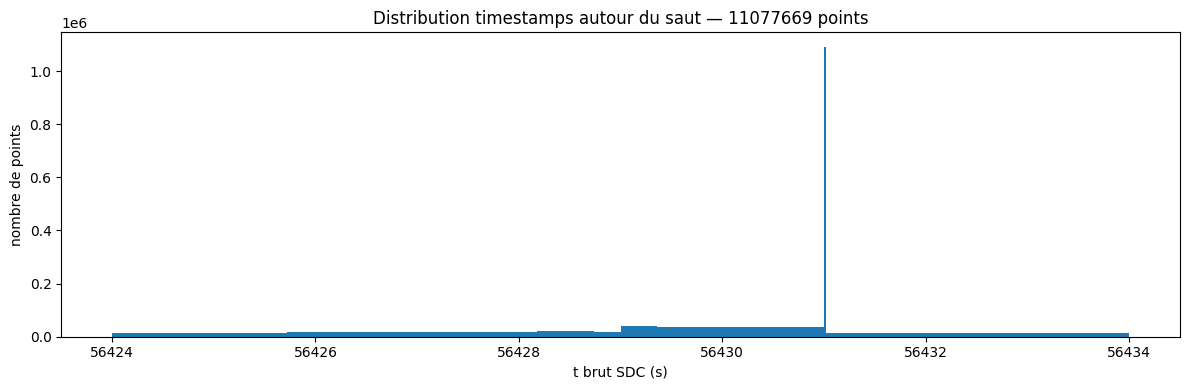

Points dans la zone : 11077669
t_min=56424.0011  t_max=56433.9990


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import struct, os
from pathlib import Path

# lecture brute sans correction
sdc_file = Path("/media/b085164/LaCie/2026spring_RD/ECCR/VUX_SDC/HA/260225_154000_VUX-HA1.sdc")

with open(sdc_file, "rb") as f:
    size_of_header = struct.unpack("<I", f.read(4))[0]

record_dtype = np.dtype([
    ("t","<f8"),("f1","<f4"),("f2","<f4"),
    ("x","<f4"),("y","<f4"),("z","<f4"),
    ("u6","<u2"),("u7","<u2"),("u8","u1"),
    ("u9","u1"),("u10","u1"),("u11","<u2"),
    ("u12","u1"),("u13","u1"),("f14","<f4"),("u15","<u2"),
])

with open(sdc_file, "rb") as f:
    f.seek(size_of_header)
    data = np.fromfile(f, dtype=record_dtype)

t = data["t"]
t = t[np.isfinite(t)]

# zone autour du saut (56429 +/- 5s)
mask = (t >= 56424) & (t <= 56434)
t_zoom = t[mask]

plt.figure(figsize=(12,4))
plt.hist(t_zoom, bins=500)
plt.xlabel("t brut SDC (s)")
plt.ylabel("nombre de points")
plt.title(f"Distribution timestamps autour du saut — {len(t_zoom)} points")
plt.tight_layout()
plt.show()
print(f"Points dans la zone : {len(t_zoom)}")
print(f"t_min={t_zoom.min():.4f}  t_max={t_zoom.max():.4f}")